In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm, glob, scipy
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

os.environ["JAX_PLATFORM_NAME"] = "cpu"
import jax
import jax.numpy as jnp
import jax_cosmo as jc

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm import camels

print(jax.devices())
print(jax.default_backend())

[CpuDevice(id=0)]
cpu


In [3]:
def halo_profile_3d(particle_pos, halo_pos, particles_in_halo_pos, num_bins=32, mesh_per_dim=512, box_size=25.0):
    particle_pos = particle_pos * mesh_per_dim / box_size
    halo_pos = halo_pos * mesh_per_dim / box_size
    particles_in_halo_pos = particles_in_halo_pos * mesh_per_dim / box_size
    
    # rho_field = cic_paint(jnp.zeros([mesh_per_dim]*3), particle_pos)
    
    rho_field = cic_paint(jnp.zeros([mesh_per_dim]*3), particles_in_halo_pos)

    nx, ny, nz = rho_field.shape
    x = jnp.arange(nx) - halo_pos[0]
    y = jnp.arange(ny) - halo_pos[1]
    z = jnp.arange(nz) - halo_pos[2]
    xx, yy, zz = jnp.meshgrid(x, y, z, indexing="ij")
    # distance from halo center
    rr = jnp.sqrt(xx**2 + yy**2 + zz**2)

    # create bins up to the max distance
    r_min = rr.min()
    r_max = jnp.quantile(jnp.sqrt(jnp.sum((particles_in_halo_pos - halo_pos) ** 2, axis=-1)), 0.95)
    bins = jnp.linspace(r_min, r_max, num_bins + 1)
    indices = jnp.digitize(rr, bins) - 1

    # sum mass in each radial bin
    mass_in_bin = []
    for i in range(num_bins):
        mass_in_bin.append(jnp.sum(rho_field * (indices == i)))
    mass_in_bin = jnp.array(mass_in_bin)

    # radius for each bin (midpoint)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    return bin_centers, mass_in_bin


# data

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0
rng = np.random.default_rng(125)

In [5]:
# mesh_per_dim = 256
# mesh_shape = [mesh_per_dim] * 3
# box_size = 25.0
# rng = np.random.default_rng(125)

In [6]:
CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS"
CODE = "SIMBA"
# CODE = "Astrid"
SIMSET = "CV"
RUN = "CV_0"

# i_snapshots = list(range(33, 0, -8))
# # i_snapshots = list(range(45, 0, -8))
# i_snapshots.sort()
i_snapshots = [-1]

SNAPSHOT = os.path.join(CAMELS, "Sims", CODE + "_DM", SIMSET, RUN, "snapshot_090.hdf5")
CATALOG = os.path.join(CAMELS, "FOF_Subfind", CODE + "_DM", SIMSET, RUN, "groups_090.hdf5")

In [7]:
# nbody_dict = camels.load_CV_snapshots(
#     os.path.join(CAMELS, "Sims", CODE + "_DM", SIMSET, RUN),
#     mesh_per_dim,
#     parts_per_dim,
#     i_snapshots=i_snapshots,
#     return_hydro=False
# )

# cosmo = nbody_dict["cosmo"]
# scales = nbody_dict["scales"]

# dm_pos = nbody_dict["dm_poss"]
# dm_vel = nbody_dict["dm_vels"]
# rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

In [8]:
# with h5py.File(SNAPSHOT, "r") as f:
#     dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
#     dm_ids = f["PartType1/ParticleIDs"][:]
    
# # i_sub = rng.choice(dm_ids, parts_per_dim**3, replace=False)
# # dm_ids = dm_ids[i_sub]
# # dm_pos = dm_pos[dm_ids]

# # rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

In [14]:
CATALOG = os.path.join(CAMELS, "FOF_Subfind", CODE, SIMSET, RUN, "groups_090.hdf5")

with h5py.File(CATALOG, "r") as f:
    h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

    print(f["Group"].keys())

    h_len_type = f['Group/GroupLenType'][:]

<KeysViewHDF5 ['GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200']>


In [26]:
(h_len_type[:,0]/h_len_type[:,1])[:10]

array([0.35554509, 0.30584873, 0.21694879, 0.16223191, 0.15549687,
       0.31420912, 0.17874325, 0.15253243, 0.16684677, 0.31005928])

(array([1.8709e+04, 1.7100e+02, 1.2000e+02, 2.2800e+02, 1.4000e+02,
        5.2000e+01, 2.6000e+01, 3.6400e+03, 2.9510e+03, 1.5960e+03,
        1.0040e+03, 8.4000e+02, 3.9900e+02, 2.8200e+02, 1.7900e+02,
        7.3000e+01, 2.9000e+01, 1.4000e+01, 1.3000e+01, 1.1000e+01,
        1.0000e+01, 4.0000e+00, 2.0000e+00, 2.0000e+00, 2.0000e+00,
        1.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([  0.  ,   4.34,   8.68,  13.02,  17.36,  21.7 ,  26.04,  30.38,
         34.72,  39.06,  43.4 ,  47.74,  52.08,  56.42,  60.76,  65.1 ,
         69.44,  73.78,  78.12,  82.46,  86.8 ,  91.14,  95.48,  99.82,
        104.16, 108.5 , 112.84, 117.18, 121.52, 125.86, 130.2 , 134.54,
        138.88, 143.22, 147.56

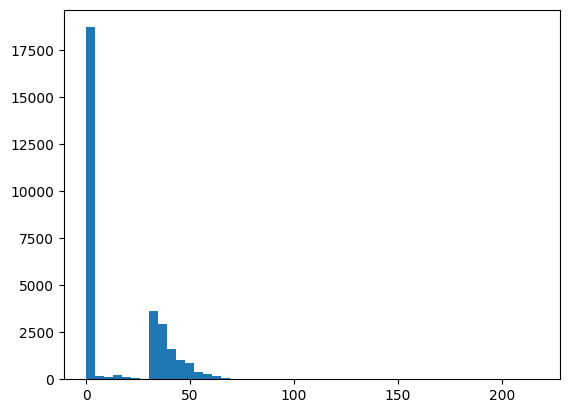

In [24]:
plt.hist(h_len_type[:,0]/h_len_type[:,1], bins=50)

# plots

(378047, 3)


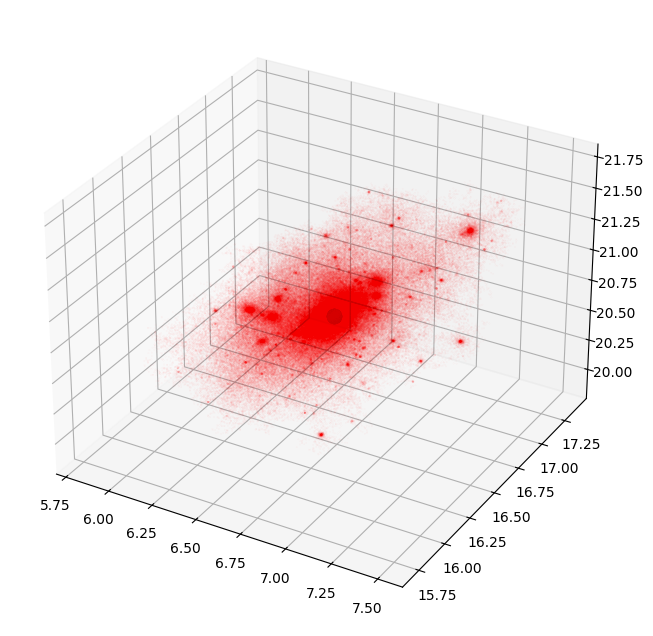

In [10]:
with h5py.File(SNAPSHOT, "r") as f:
    # dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_pos = f["PartType1/Coordinates"][:] / 1e3
    dm_ids = f["PartType1/ParticleIDs"][:]

with h5py.File(CATALOG, "r") as f:
    # h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_pos = f['Group/GroupPos'][:] / 1e3
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

# i_halo = np.argmax(h_mass)
i_halo = 2
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
halo_pos = h_pos[i_halo]

dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
print(dm_pos_halo.shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

In [11]:
# with h5py.File(SNAPSHOT, "r") as f:
#     # dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
#     dm_pos = f["PartType1/Coordinates"][:] / 1e3
#     dm_ids = f["PartType1/ParticleIDs"][:]

# with h5py.File(CATALOG, "r") as f:
#     # h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
#     h_pos = f['Group/GroupPos'][:] / 1e3
#     h_mass = f['Group/GroupMass'][:] * 1e10
#     h_len = f['Group/GroupLen'][:]
#     h_ids = f['IDs']['ID'][:]

# # i_halo = np.argmax(h_mass)
# i_halo = 2
# start = np.sum(h_len[:i_halo])
# end = start+h_len[i_halo]
# h_ids_halo = h_ids[start:end]
# dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]

# i_sub = rng.choice(dm_ids, parts_per_dim**3, replace=False)
# dm_pos = dm_pos[np.isin(dm_ids, i_sub)]
# dm_pos_halo = dm_pos_halo[np.isin(h_ids_halo, i_sub)]
# print(dm_pos_halo.shape)

# fig = plt.figure(figsize=(16, 8))
# ax = fig.add_subplot(211, projection='3d')

# ax.scatter(dm_pos[:, 0], dm_pos[:, 1], dm_pos[:, 2], c='b', marker='o', alpha=0.1, s=0.01)
# ax.scatter(dm_pos_halo[:, 0], dm_pos_halo[:, 1], dm_pos_halo[:, 2], c='r', marker='o', s=0.01)
# ax.scatter(h_pos[i_halo,0], h_pos[i_halo,1], h_pos[i_halo,2], c='g', marker='o', s=100)

# ax = fig.add_subplot(212, projection='3d')
# ax.scatter(dm_pos_halo[:, 0], dm_pos_halo[:, 1], dm_pos_halo[:, 2], c='r', marker='o', s=0.01)
# ax.scatter(h_pos[i_halo,0], h_pos[i_halo,1], h_pos[i_halo,2], c='g', marker='o', s=100)

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass')]

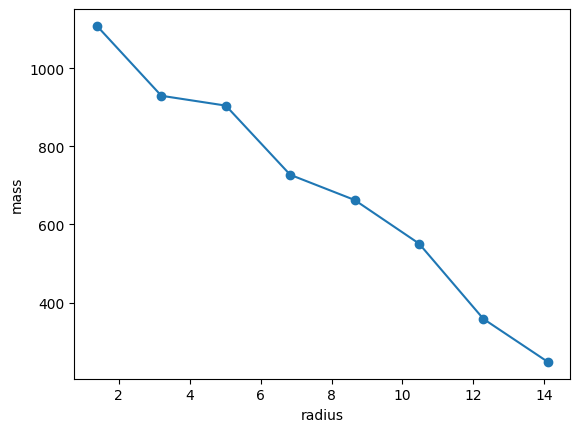

In [58]:
r, profile = halo_profile_3d(dm_pos, halo_pos, dm_pos_halo, num_bins=8)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
ax.set(xlabel="radius", ylabel="mass")
# ax.set(xlabel="radius", ylabel="mass", xscale="log", yscale="log")

# hydro

In [12]:
from jaxpm.utils import halo_density_profile

parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0

519254 particles in halo
367430 dm particles in halo
112739 gas particles in halo


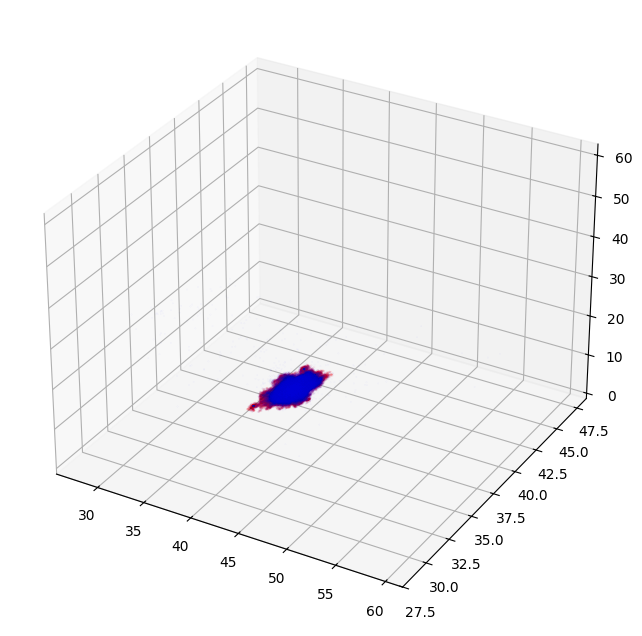

In [13]:
SNAPSHOT = os.path.join(CAMELS, "Sims", CODE, SIMSET, RUN, "snapshot_090.hdf5")
CATALOG = os.path.join(CAMELS, "FOF_Subfind", CODE, SIMSET, RUN, "groups_090.hdf5")

with h5py.File(SNAPSHOT, "r") as f:
    dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_ids = f["PartType1/ParticleIDs"][:]
    
    gas_pos = f["PartType0/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    gas_ids = f["PartType0/ParticleIDs"][:]
    gas_mass = f["PartType0/Masses"][:]

with h5py.File(CATALOG, "r") as f:
    h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

# i_halo = np.argmax(h_mass)
i_halo = 1
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
halo_pos = h_pos[i_halo]

dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
gas_pos_halo = gas_pos[np.isin(gas_ids, h_ids_halo)]
gas_mass_halo = gas_mass[np.isin(gas_ids, h_ids_halo)]
print(f"{len(h_ids_halo)} particles in halo")
print(f"{len(dm_pos_halo)} dm particles in halo")
print(f"{len(gas_pos_halo)} gas particles in halo")

# i_sub = rng.choice(dm_ids, parts_per_dim**3, replace=False)
# dm_pos = dm_pos[np.isin(dm_ids, i_sub)]
# dm_pos_halo = dm_pos_halo[np.isin(h_ids_halo, i_sub)]

# i_sub = rng.choice(gas_ids, parts_per_dim**3, replace=False)
# gas_pos = dm_pos[np.isin(gas_ids, i_sub)]
# gas_pos_halo = gas_pos_halo[np.isin(h_ids_halo, i_sub)]

# # TODO
# n_dm_in_halo = dm_pos_halo.shape[0]
# i_sub = rng.choice(np.arange(n_dm_in_halo), n_dm_in_halo//64, replace=False)
# dm_pos_halo = dm_pos_halo[i_sub]

# n_gas_in_halo = gas_pos_halo.shape[0]
# i_sub = rng.choice(np.arange(n_gas_in_halo), n_gas_in_halo//64, replace=False)
# gas_pos_halo = gas_pos_halo[i_sub]

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[gas_pos_halo[:,i] for i in range(3)], c='b', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

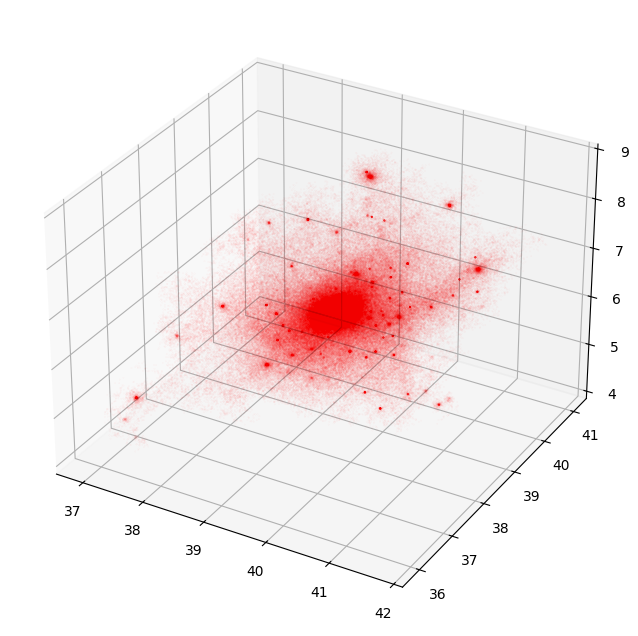

In [14]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)

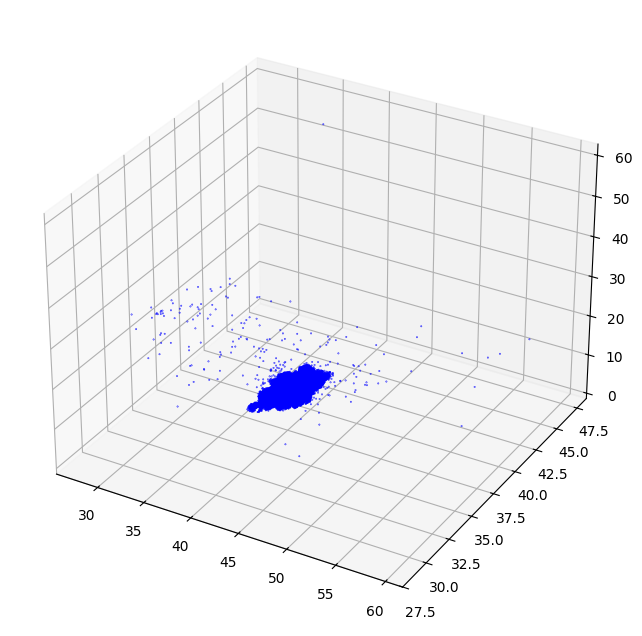

In [15]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[gas_pos_halo[:,i] for i in range(3)], c='b', marker='o', s=0.1, alpha=1)

[Text(0.5, 0, 'radius [pm]'),
 Text(0, 0.5, 'density [arbitrary units]'),
 None,
 None,
 Text(0.5, 1.0, 'dark matter')]

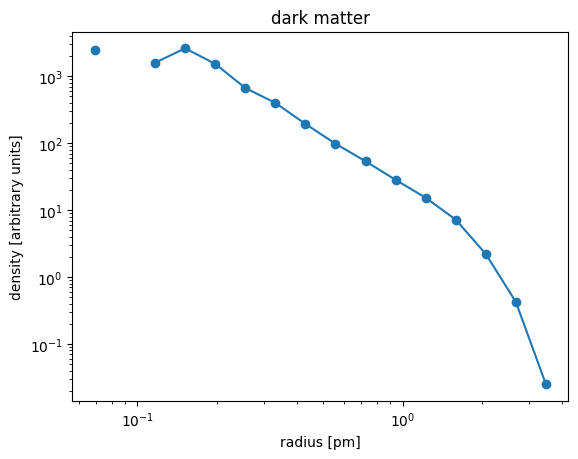

In [18]:
r, profile = halo_density_profile(dm_pos_halo, halo_pos, num_bins=16, mesh_per_dim_input=64, r_max_quantile=1.0)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
# ax.set(xlabel="radius [Mpc/h]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="dark matter")
ax.set(xlabel="radius [pm]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="dark matter")

[Text(0.5, 0, 'radius [pm]'),
 Text(0, 0.5, 'density [arbitrary units]'),
 None,
 None,
 Text(0.5, 1.0, 'gas')]

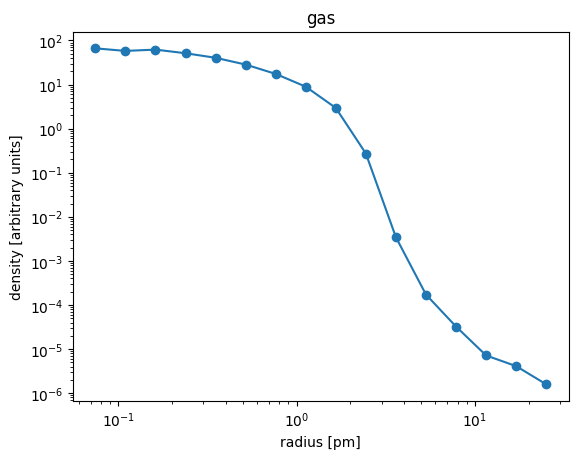

In [19]:
r, profile = halo_density_profile(gas_pos_halo, halo_pos, num_bins=16, mesh_per_dim_input=64, r_max_quantile=1.0)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
# ax.set(xlabel="radius [Mpc/h]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="gas")
ax.set(xlabel="radius [pm]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="gas")

In [136]:
def halo_profile_3d(halo_particle_pos, halo_pos, halo_particle_mass=None, num_bins=32, mesh_per_dim=512, box_size=25.0, periodic=True):
    halo_particle_pos = halo_particle_pos * mesh_per_dim / box_size
    halo_pos = halo_pos * mesh_per_dim / box_size

    if halo_particle_mass is None:
        rho_field = cic_paint(jnp.zeros([mesh_per_dim] * 3), halo_particle_pos)
    else:
        rho_field = cic_paint(jnp.zeros([mesh_per_dim] * 3), halo_particle_pos, halo_particle_mass)

    nx, ny, nz = rho_field.shape

    # Helper function to do periodic distance
    def pbc_distance(coord, center, length):
        return (coord - center + length / 2) % length - length / 2

    if periodic:
        x = pbc_distance(jnp.arange(nx), halo_pos[0], nx)
        y = pbc_distance(jnp.arange(ny), halo_pos[1], ny)
        z = pbc_distance(jnp.arange(nz), halo_pos[2], nz)
    else:
        x = jnp.arange(nx) - halo_pos[0]
        y = jnp.arange(ny) - halo_pos[1]
        z = jnp.arange(nz) - halo_pos[2]

    xx, yy, zz = jnp.meshgrid(x, y, z, indexing="ij")
    rr = jnp.sqrt(xx**2 + yy**2 + zz**2)

    # create bins up to the max distance
    r_min = rr.min()
    if periodic:
        r_max = jnp.quantile(jnp.sqrt(jnp.sum(((halo_particle_pos - halo_pos + mesh_per_dim / 2) % mesh_per_dim - mesh_per_dim / 2) ** 2, axis=-1)), 0.99)
    else:
        r_max = jnp.quantile(jnp.sqrt(jnp.sum((halo_particle_pos - halo_pos) ** 2, axis=-1)), 0.99)
        # r_max = jnp.sqrt(jnp.sum((halo_particle_pos - halo_pos) ** 2, axis=-1)).max()
    bins = jnp.linspace(r_min, r_max, num_bins + 1)
    indices = jnp.digitize(rr, bins) - 1

    mass_in_bin = []
    for i in range(num_bins):
        mass_in_bin.append(jnp.mean(rho_field[indices == i]))
    mass_in_bin = jnp.array(mass_in_bin)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # go back to mpc
    print(bin_centers)
    bin_centers *= box_size / mesh_per_dim
    print(bin_centers)
    return bin_centers, mass_in_bin


In [16]:
r, profile = halo_profile_3d(dm_pos_halo, halo_pos, num_bins=16, mesh_per_dim=512, periodic=False)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
# ax.set(xlabel="radius", ylabel="mass")
ax.set(xlabel="radius [Mpc/h]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="dark matter")

TypeError: halo_profile_3d() got an unexpected keyword argument 'periodic'

In [17]:
r, profile = halo_profile_3d(gas_pos_halo, halo_pos, num_bins=16, mesh_per_dim=512, periodic=False)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
# ax.set(xlabel="radius", ylabel="mass")
ax.set(xlabel="radius [Mpc/h]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title="gas")

TypeError: halo_profile_3d() got an unexpected keyword argument 'periodic'

In [108]:
rho_field = cic_paint(jnp.zeros([mesh_per_dim] * 3), dm_pos_halo)
nx, ny, nz = rho_field.shape

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass')]

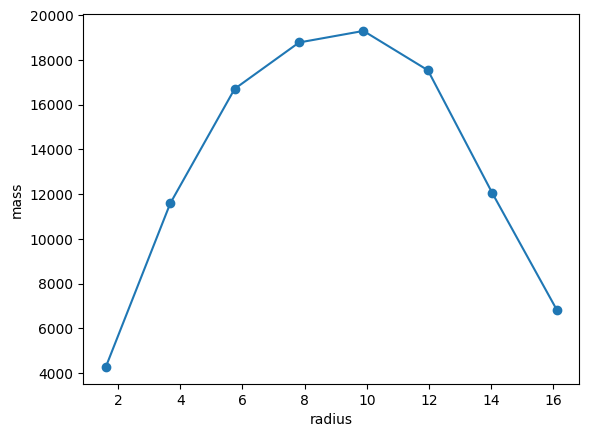

In [57]:
r, profile = halo_profile_3d(gas_pos_halo, halo_pos, num_bins=8)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
ax.set(xlabel="radius", ylabel="mass")
# ax.set(xlabel="radius", ylabel="mass", xscale="log", yscale="log")

[Text(0.5, 0, 'radius'), Text(0, 0.5, 'mass'), None, None]

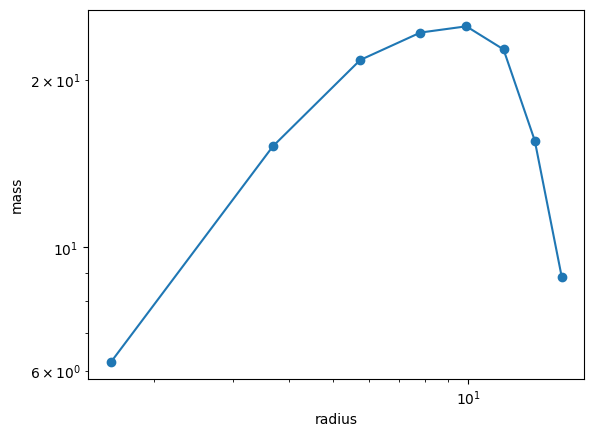

In [59]:
r, profile = halo_profile_3d(gas_pos_halo, halo_pos, gas_mass_halo, num_bins=8)

fig, ax = plt.subplots()

ax.plot(r, profile, marker='o')
# ax.set(xlabel="radius", ylabel="mass")
ax.set(xlabel="radius", ylabel="mass", xscale="log", yscale="log")

# CAMELS ground truth profile

In [71]:
PROFILE = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Profiles/SIMBA/CV/CV_0/SIMBA_CV_0_033.hdf5"

# see https://camels.readthedocs.io/en/latest/Profiles.html
with h5py.File(PROFILE, "r") as f:
    val = f['Profiles'][:]
    density = np.array(val[0,:,:]) # some unknown units
    r = np.array(f['r'])

    print(f['nprofs'][()], "halos")


344 halos


In [63]:
density.shape

(344, 25)

In [66]:
r.shape

(25,)

In [75]:
density[0].shape

(25,)

In [77]:
r.shape

(25,)

[None, None]

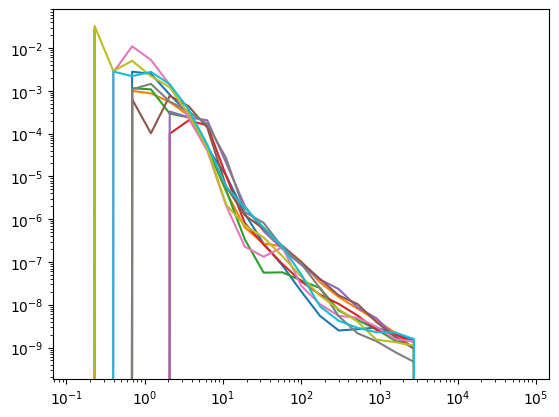

In [80]:
fig, ax = plt.subplots()

for i in range(10):
    ax.plot(r, density[i])
ax.set(yscale="log", xscale="log")

# subselection

(378047, 3)


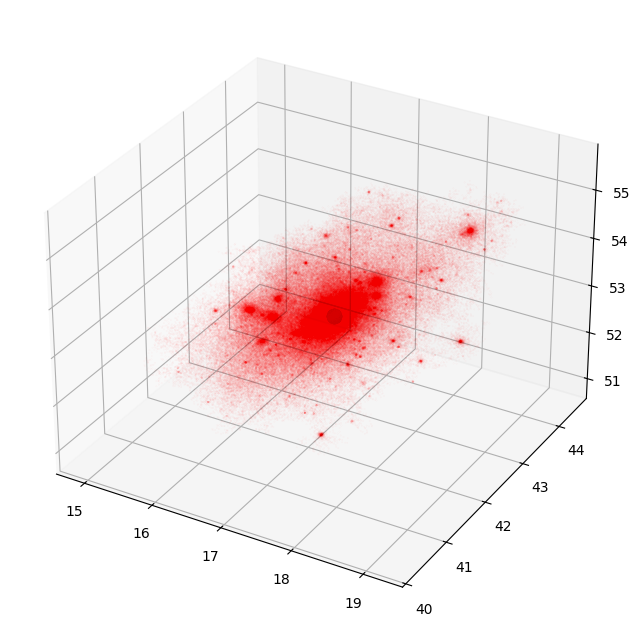

In [49]:
with h5py.File(SNAPSHOT, "r") as f:
    dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_ids = f["PartType1/ParticleIDs"][:]

with h5py.File(CATALOG, "r") as f:
    h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

# i_halo = np.argmax(h_mass)
i_halo = 2
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
halo_pos = h_pos[i_halo]

dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
print(dm_pos_halo.shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

In [53]:
np.isin(dm_ids, h_ids_halo).shape

(262144,)

In [57]:
h_len

array([813839, 381692, 378047, ...,     32,     32,     32], dtype=int32)

In [63]:
def _subsample_ordered_particles_in_boxes(particles, in_particles=256, out_particles=64):
    """
    It's important that the particles are ordered by index. Adapted from:
    https://github.com/DifferentiableUniverseInitiative/jaxpm-paper/blob/main/notebooks/dev/CAMELS_Fitting_PosVel.ipynb
    """

    assert in_particles % out_particles == 0

    dims = particles.shape[-1]
    sub_fac = in_particles // out_particles

    # divide the simulation volume into sub_fac x sub_fac x sub_fac boxes containing out_particles each
    particles = (
        particles.reshape(sub_fac, sub_fac, sub_fac, out_particles, out_particles, out_particles, dims)
        .transpose(0, 3, 1, 4, 2, 5, 6)
        .reshape(-1, dims)
    )
    # downsampling
    particles = particles.reshape([in_particles, in_particles, in_particles, dims])[
        ::sub_fac, ::sub_fac, ::sub_fac, :
    ].reshape([-1, dims])

    return particles


(5596, 3)


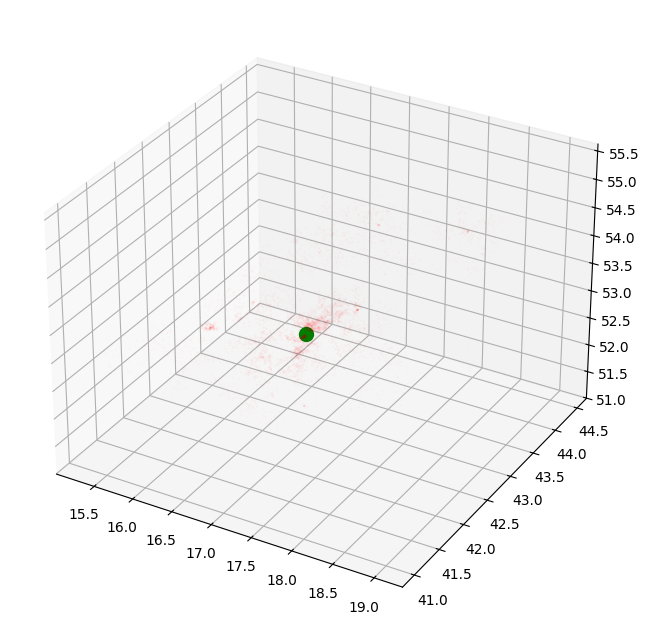

In [72]:
with h5py.File(SNAPSHOT, "r") as f:
    dm_pos = f["PartType1/Coordinates"][:]  * mesh_per_dim / (1e3 * box_size)
    dm_ids = f["PartType1/ParticleIDs"][:]

# subselection_mask = np.isin(dm_ids, np.random.choice(dm_ids, 64**3, replace=False))
# dm_pos = dm_pos[subselection_mask]
# dm_ids = dm_ids[subselection_mask]

dm_pos = _subsample_ordered_particles_in_boxes(dm_pos, in_particles=256, out_particles=parts_per_dim)
dm_ids = np.squeeze(_subsample_ordered_particles_in_boxes(dm_ids[...,np.newaxis], in_particles=256, out_particles=parts_per_dim))

# dm_ids = dm_ids.reshape(-1)

# # Reshape to 3D grid and subsample
# dm_ids_3d = dm_ids.reshape([256, 256, 256])
# dm_ids = dm_ids_3d[::4, ::4, ::4]

# dm_ids = dm_ids.reshape(-1)

with h5py.File(CATALOG, "r") as f:
    h_pos = f['Group/GroupPos'][:]  * mesh_per_dim / (1e3 * box_size) 
    h_mass = f['Group/GroupMass'][:] * 1e10
    h_len = f['Group/GroupLen'][:]
    h_ids = f['IDs']['ID'][:]

i_halo = 2
start = np.sum(h_len[:i_halo])
end = start+h_len[i_halo]
h_ids_halo = h_ids[start:end]
halo_pos = h_pos[i_halo]

dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
print(dm_pos_halo.shape)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=0.01, alpha=0.1)
ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

In [11]:
from jaxpm import camels, utils
from tqdm import tqdm

In [12]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0
rng = np.random.default_rng(125)

In [21]:
snapshot_dict = camels.load_CV_snapshots(
    "CV_0",
    mesh_per_dim,
    # parts_per_dim=parts_per_dim,
    parts_per_dim=None,
    i_snapshots=[-1],
    # hydro=False,
)

cosmo = snapshot_dict["cosmo"]

dm_pos = snapshot_dict["dm_poss"]
dm_ids = snapshot_dict["dm_ids"]

gas_pos = snapshot_dict["gas_poss"]
gas_ids = snapshot_dict["gas_ids"]

h_pos = snapshot_dict["h_poss"]
h_len = snapshot_dict["h_lens"]
h_ids = snapshot_dict["h_ids"]

dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)
gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Using all particles


loading snapshots: 100%|██████████| 1/1 [00:12<00:00, 12.60s/it]

Could not stack h_masss


In [22]:
# i_halo = 1
# halo_pos = h_pos[i_halo]

# start = np.sum(h_len[:i_halo])
# end = start+h_len[i_halo]
# h_ids_halo = h_ids[start:end]

# dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
# gas_pos_halo = gas_pos[np.isin(gas_ids, h_ids_halo)]
# print(dm_pos_halo.shape)
# print(gas_pos_halo.shape)

# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(*[dm_pos_halo[:,i] for i in range(3)], c='r', marker='o', s=1, alpha=0.1, label="dark matter")
# ax.scatter(*[gas_pos_halo[:,i] for i in range(3)], c='b', marker='o', s=1, alpha=0.1, label="gas")
# ax.scatter(*[halo_pos[i] for i in range(3)], c='g', marker='o', s=100)

In [23]:
# r, dm_profile = utils.halo_density_profile(dm_pos_halo, halo_pos, num_bins=8, mesh_per_dim_input=64, r_max_quantile=0.99)
# r, gas_profile = utils.halo_density_profile(gas_pos_halo, halo_pos, num_bins=8, mesh_per_dim_input=64, r_max_quantile=0.99)

# fig, ax = plt.subplots()

# ax.plot(r, dm_profile, marker='o', label="dark matter")
# ax.plot(r, gas_profile, marker='o', label="gas")

# ax.set(xlabel="radius [pm]", ylabel="density [arbitrary units]", xscale="log", yscale="log")

In [24]:
gas_mass/dm_mass

0.19521912350597612

In [25]:
for i in tqdm(range(n_examples)):
    halo_pos = h_pos[i]
    
    start = np.sum(h_len[:i])
    end = start+h_len[i]
    h_ids_halo = h_ids[start:end]
    
    dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
    gas_pos_halo = gas_pos[np.isin(gas_ids, h_ids_halo)]
    
    print(len(gas_pos_halo)/len(dm_pos_halo))


  8%|▊         | 1/12 [00:00<00:02,  4.66it/s]

0.35662840449843497


 25%|██▌       | 3/12 [00:00<00:01,  5.25it/s]

0.30683123316005767
0.21721926979620962


 42%|████▏     | 5/12 [00:00<00:01,  5.18it/s]

...

0.15295699372304825
0.1678640776699029


 92%|█████████▏| 11/12 [00:02<00:00,  5.47it/s]

0.31010085053667785
0.16732373009855953


100%|██████████| 12/12 [00:02<00:00,  5.42it/s]

0.19806953868812793


  0%|          | 0/12 [00:00<?, ?it/s]

0.37318427256825615


  8%|▊         | 1/12 [00:08<01:30,  8.25s/it]

0.3145775623268698


 17%|█▋        | 2/12 [00:16<01:22,  8.21s/it]

...

 83%|████████▎ | 10/12 [01:21<00:16,  8.16s/it]

0.1830065359477124


 92%|█████████▏| 11/12 [01:29<00:08,  8.15s/it]

0.20435510887772193


100%|██████████| 12/12 [01:37<00:00,  8.13s/it]


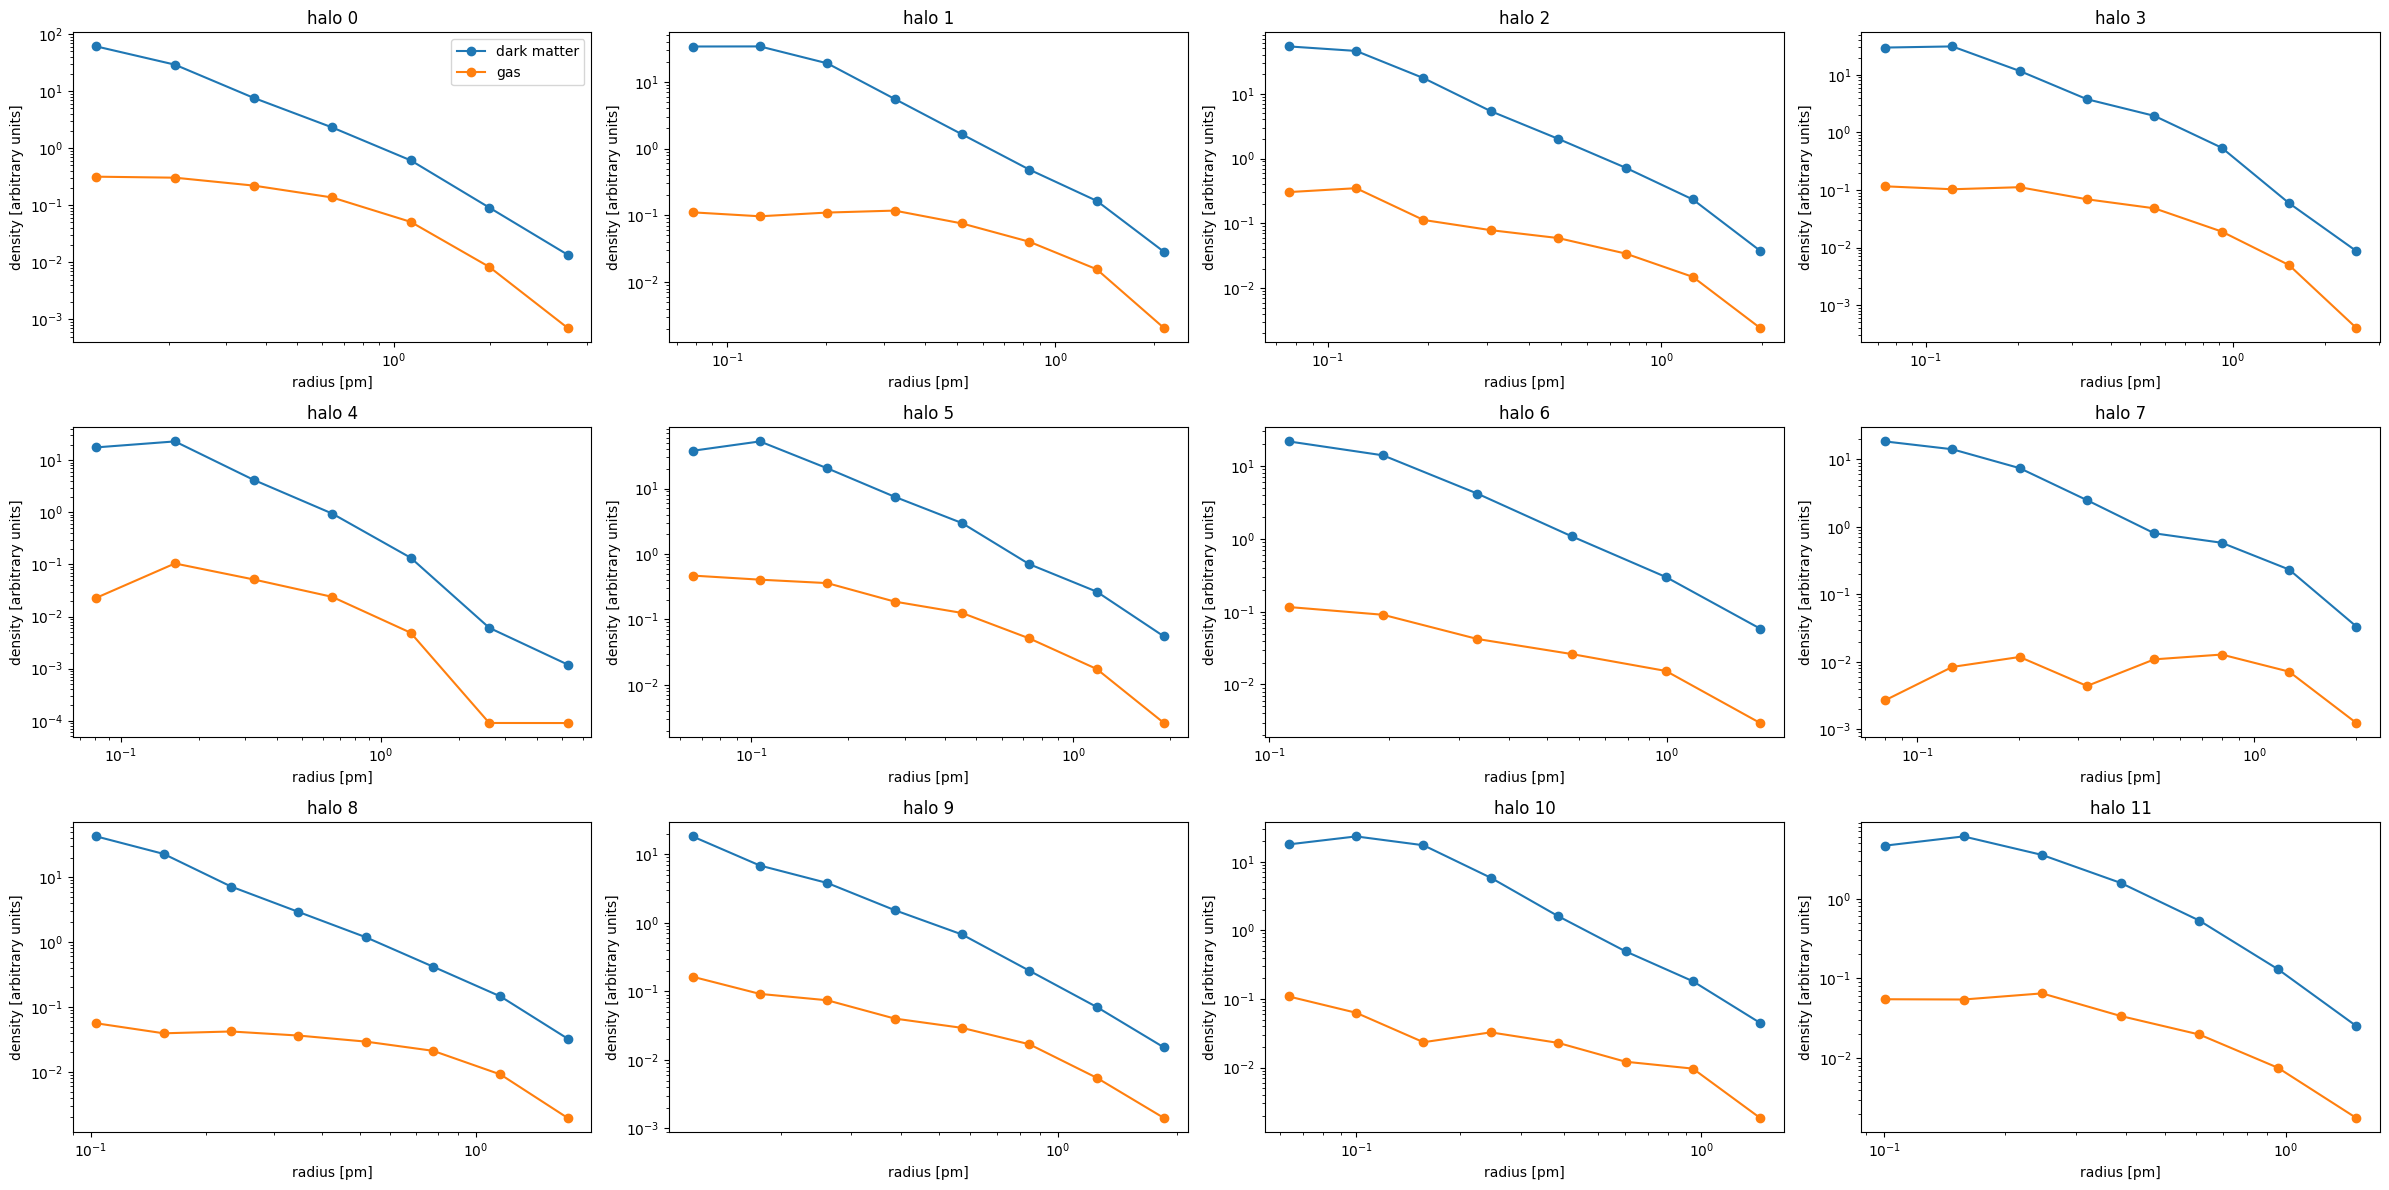

In [20]:
n_rows = 3
n_cols = 4
n_examples = n_rows * n_cols

fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(6*n_cols, 4*n_rows))

ax = ax.flatten()
for i in tqdm(range(n_examples)):
    halo_pos = h_pos[i]
    
    start = np.sum(h_len[:i])
    end = start+h_len[i]
    h_ids_halo = h_ids[start:end]
    
    dm_pos_halo = dm_pos[np.isin(dm_ids, h_ids_halo)]
    gas_pos_halo = gas_pos[np.isin(gas_ids, h_ids_halo)]

    print(len(gas_pos_halo)/len(dm_pos_halo))

    r, dm_profile = utils.halo_density_profile(dm_pos_halo, halo_pos, dm_mass, num_bins=8, mesh_per_dim_input=64, r_max_quantile=0.99)
    r, gas_profile = utils.halo_density_profile(gas_pos_halo, halo_pos, gas_mass, num_bins=8, mesh_per_dim_input=64, r_max_quantile=0.99)
    
    ax[i].plot(r, dm_profile, marker='o', label="dark matter")
    ax[i].plot(r, gas_profile, marker='o', label="gas")
    
    ax[i].set(xlabel="radius [pm]", ylabel="density [arbitrary units]", xscale="log", yscale="log", title=f"halo {i}")

ax[0].legend()

fig.tight_layout()